## Task 1

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

### Step 1

In [2]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# rows and columns
df.shape

(768, 9)

In [4]:
# types of columns
# missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# descriptive statistics
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [6]:
# I delete rows where BMI equals to 0(zero)
df = df.drop(df[df['BMI'] == 0].index)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
# I replace zero(0) with np.nan in Insulin column
df['Insulin'] = df['Insulin'].replace(0, np.nan)

# I fill np.nan with median of groups
df['Insulin'] = df['Insulin'].fillna(df.groupby('Outcome')['Insulin'].transform('median')) 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,169.5,33.6,0.627,50,1
1,1,85,66,29,105.0,26.6,0.351,31,0
2,8,183,64,0,169.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,105.0,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,0,169.5,30.1,0.349,47,1


In [8]:
# I replace zero(0) with np.nan in SkinThickness column
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)

# I fill np.nan with median of groups
df['SkinThickness'] = df['SkinThickness'].fillna(df.groupby('Outcome')['SkinThickness'].transform('median')) 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,169.5,33.6,0.627,50,1
1,1,85,66,29.0,105.0,26.6,0.351,31,0
2,8,183,64,32.0,169.5,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,105.0,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,32.0,169.5,30.1,0.349,47,1


In [9]:
# I replace zero(0) with np.nan in Glucose column
df['Glucose'] = df['Glucose'].replace(0, np.nan)

# I fill np.nan with medain of groups
df['Glucose'] = df['Glucose'].fillna(df.groupby('Outcome')['Glucose'].transform('median')) 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66,29.0,105.0,26.6,0.351,31,0
2,8,183.0,64,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70,27.0,105.0,36.8,0.340,27,0
765,5,121.0,72,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60,32.0,169.5,30.1,0.349,47,1


In [10]:
# I replace zero(0) with np.nan in BloodPressure column
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)

# I fill np.nan with median of groups
df['BloodPressure'] = df['BloodPressure'].fillna(df.groupby('Outcome')['BloodPressure'].transform('median')) 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,105.0,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,105.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,32.0,169.5,30.1,0.349,47,1


In [11]:
df.describe().loc['min']

Pregnancies                  0.000
Glucose                     44.000
BloodPressure               24.000
SkinThickness                7.000
Insulin                     14.000
BMI                         18.200
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
Name: min, dtype: float64

### Visualisation

<Axes: >

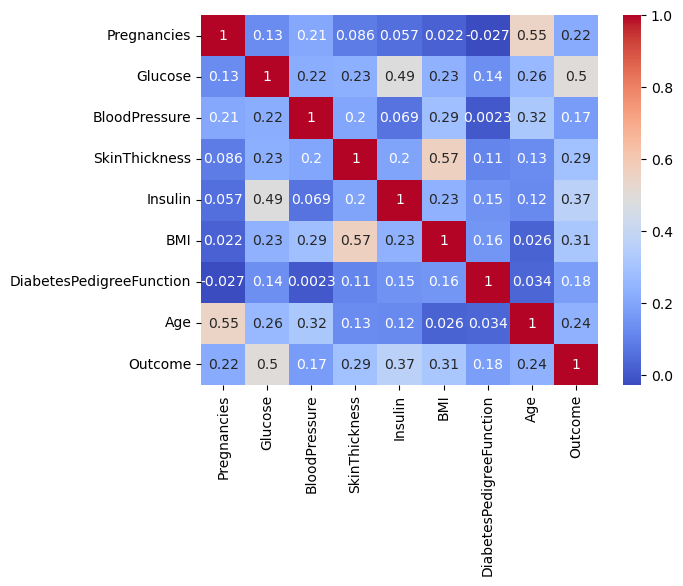

In [12]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

##### Glucose is now the Leader: The correlation with Outcome is 0.5. This is the strongest correlation in the dataset.

<Axes: xlabel='Outcome', ylabel='Glucose'>

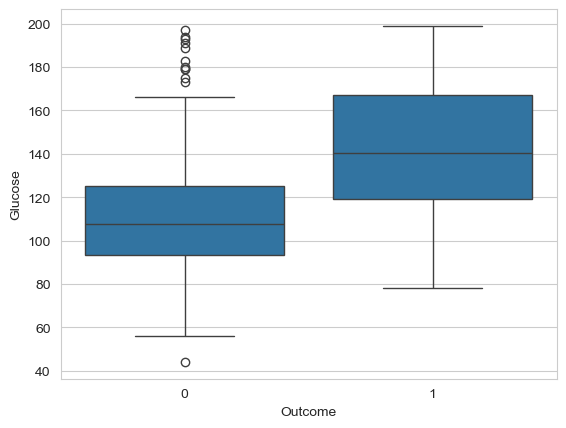

In [32]:
sns.boxplot(data=df, x='Outcome', y='Glucose')

<Axes: xlabel='Glucose', ylabel='BMI'>

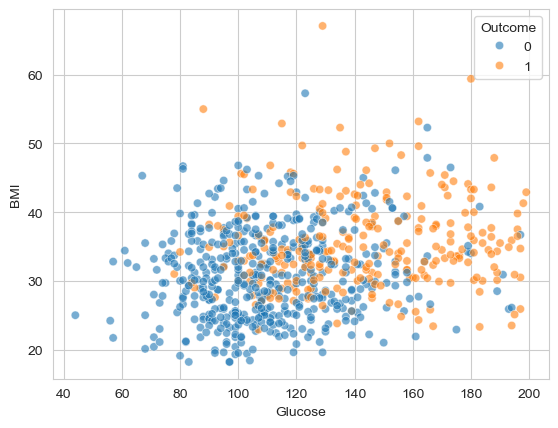

In [33]:
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', alpha=0.6)

<Axes: xlabel='Age', ylabel='Density'>

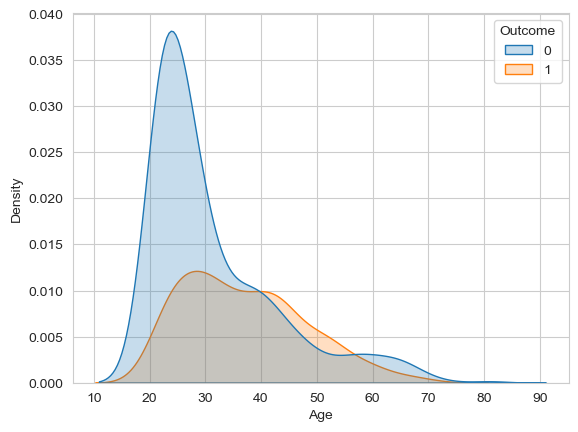

In [34]:
sns.kdeplot(data=df, x='Age', hue='Outcome', fill=True)

<Axes: xlabel='Outcome', ylabel='Glucose'>

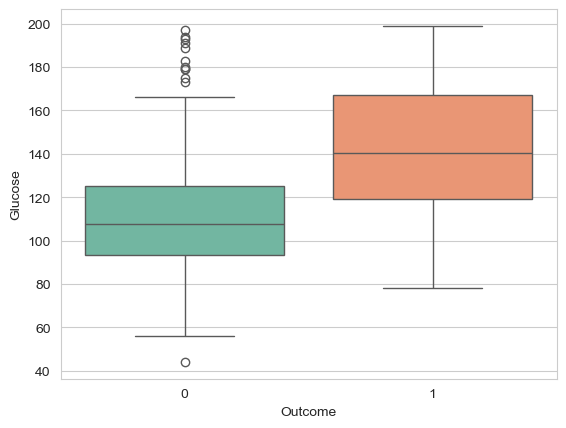

In [35]:
sns.boxplot(data=df, x='Outcome', y='Glucose', hue='Outcome', palette='Set2', legend=False)

The median of the healthy group (0) (the line in the middle of the green box) is around 107. The median of the diabetic group (1) is over 140. These two boxes are so far apart that the area of ​​intersection is very small. Glucose is 805 enough to predict

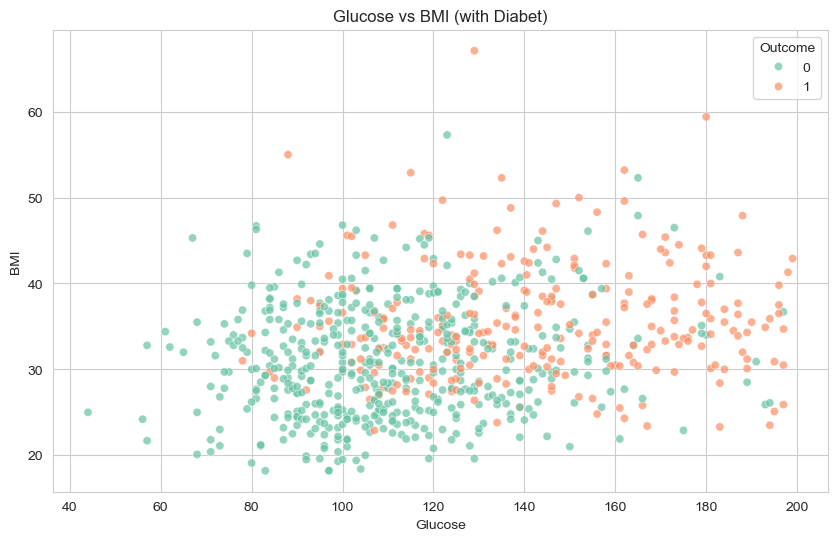

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', alpha=0.7, palette='Set2')
plt.title('Glucose vs BMI (with Diabet)')
plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>, <Axes: >]], dtype=object)

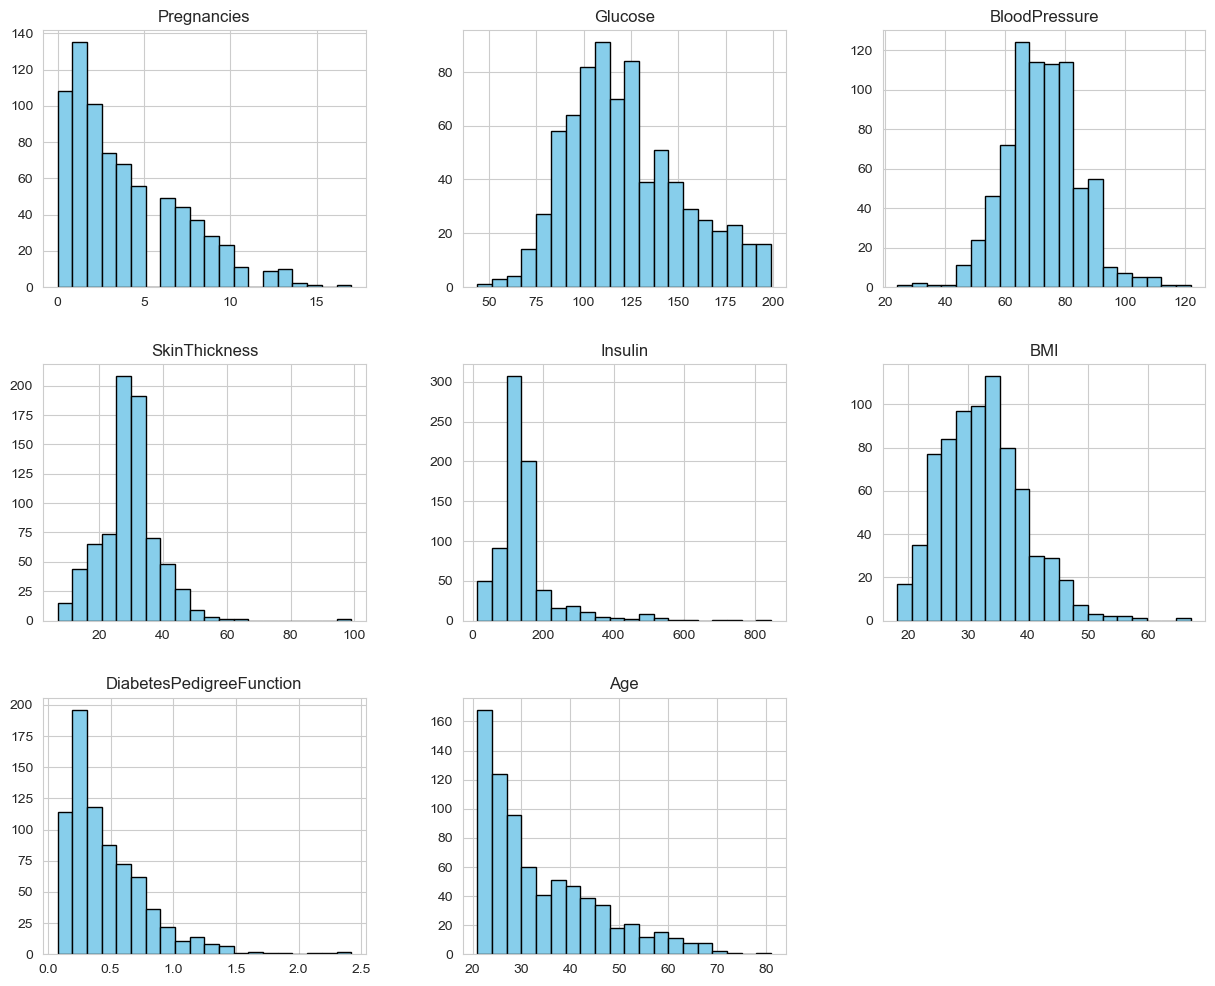

In [38]:
df.drop('Outcome', axis=1).hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')

### Step 2

Shapiro-Wilk P-value: 2.4548125138027663e-11


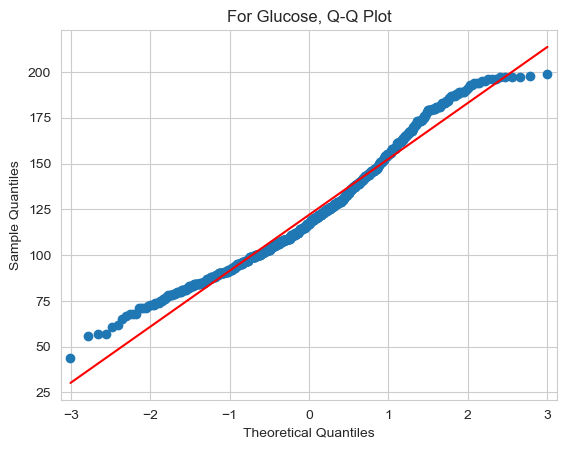

In [39]:
import statsmodels.api as sm

# Checking normality

# Shapiro-Wilk Test
shapiro_test = st.shapiro(df['Glucose'])
print(f"Shapiro-Wilk P-value: {shapiro_test.pvalue}")

# Q-Q Plot visualisation
sm.qqplot(df['Glucose'], line='s')
plt.title("For Glucose, Q-Q Plot")
plt.show()

In [40]:
# Levene's Test (between groups of "Outcome")
group0 = df[df['Outcome'] == 0]['Glucose']
group1 = df[df['Outcome'] == 1]['Glucose']
levene_test = st.levene(group0, group1)
print(f"Levene's Test P-value: {levene_test.pvalue}")

Levene's Test P-value: 2.5846719787315745e-06


### Step 3

In Shapiro-Wilk Test, p value is 2.4548125138027663e-11 = 0.0000000000245
p < 0.05
The Q-Q Plot visualization showed that the points deviated significantly from the ideal line (especially in the tails)
That's why Glucose data is not exactly normally distributed

In Levene's Test, p-value is 2.5846719787315745e-06 = 0.00000258
p < 0.05
that's why varaiances are not equal

During hypothesis testing, both normality (Shapiro-Wilk, p < 0.05) and equality of variance (Levene, p < 0.05) conditions were found to be violated. Since these violations could make the results of the standard Student's T-test inaccurate, I preferred the more reliable nonparametric Mann-Whitney U test.

## Task 2

### Question 1

Is there a statistically significant difference between the Glucose levels of patients diagnosed with diabetes and healthy patients?

Null hypothesis ($H_0$): Glucose distributions are the same in diabetic and healthy individuals

Alternative hypothesis ($H_1$): There is difference between glucose distributions in diabetic and healthy individuals

#### Justifictaion of my choice of test
The Q-Q Plot visualization showed that the points deviated significantly from the ideal line (especially in the tails). That's why Glucose data is not exactly normally distributed.).And in Levene's Test, p-value is 2.5846719787315745e-06 = 0.00000258 p < 0.05 that's why varaiances are not equal. Since these violations can make the results of the standard Student's T-test inaccurate, I preferred the more reliable nonparametric Mann-Whitney U test. 

In [41]:
from scipy.stats import mannwhitneyu

# I divide into groups
healthy = df[df['Outcome'] == 0]['Glucose']
diabetic = df[df['Outcome'] == 1]['Glucose']

# Execution of Mann-Whitney U test
u_stat, p_val = mannwhitneyu(healthy, diabetic)

# Effect size(r)
n1, n2 = len(healthy), len(diabetic)
r = 1 - (2 * u_stat) / (n1 * n2)

print(f"U-statistic: {u_stat}")
print(f"P-value: {p_val}")
print(f"Effect Size (r): {abs(r).round(3)}")

U-statistic: 27004.5
P-value: 1.4553041337967857e-40
Effect Size (r): 0.586


#### Conclusion
p < 0.05, it shows that the difference between glucose levels of healthy and diabetic patients are not random and we reject null hypothesis ($H_0$). Also being high of effect size(r=0.586) shows that it is practically important. Shortly, Glucose level in diabetic patients are much higher than healthy patients

### Question 2

Is the risk of diabetes (Outcome) higher in patients with a high BMI ?

Null hypothesis ($H_0$): The BMI distribution is the same between diabetic and healthy individuals
Alternative hypothesis ($H_1$): The BMI distribution between diabetic and healthy individuals is statistically different.

In [42]:
shapiro_test = st.shapiro(df['BMI'])
print(f"Shapiro-Wilk P-value: {shapiro_test.pvalue}")

Shapiro-Wilk P-value: 8.557784159781197e-09


#### Justification of my choice of test
BMI data is not perfectly normally distributed

In [43]:
# I divide into groups
bmi_healthy = df[df['Outcome'] == 0]['BMI']
bmi_diabetic = df[df['Outcome'] == 1]['BMI']

# Execution of Mann-Whitney U test
u_bmi, p_bmi = mannwhitneyu(bmi_healthy, bmi_diabetic)

# Effect size(r)
n1, n2 = len(bmi_healthy), len(bmi_diabetic)
r = 1 - (2 * u_stat) / (n1 * n2)

print(f"BMI U-statistic: {u_stat}")
print(f"BMI P-value: {p_val}")
print(f"BMI Effect Size (r): {abs(r).round(3)}")

BMI U-statistic: 27004.5
BMI P-value: 1.4553041337967857e-40
BMI Effect Size (r): 0.586


#### Conclusion
BMI P-value < 0.05 and effect size r = 0.374, that's why we reject $H_0$. It shows that people diagnosed with diabetes have a higher body mass index than healthy people. 

### Question 3

Is there a statistically significant correlation between the age of the patients and insulin levels?

Null hypothesis ($H_0$): 
There is no statistical relationship between the age of the patients and insulin levels ($\rho = 0$)

Alternative hypothesis ($H_1$): There is a statistically significant relationship between the age of the patients and insulin levels ($\rho \neq 0$)


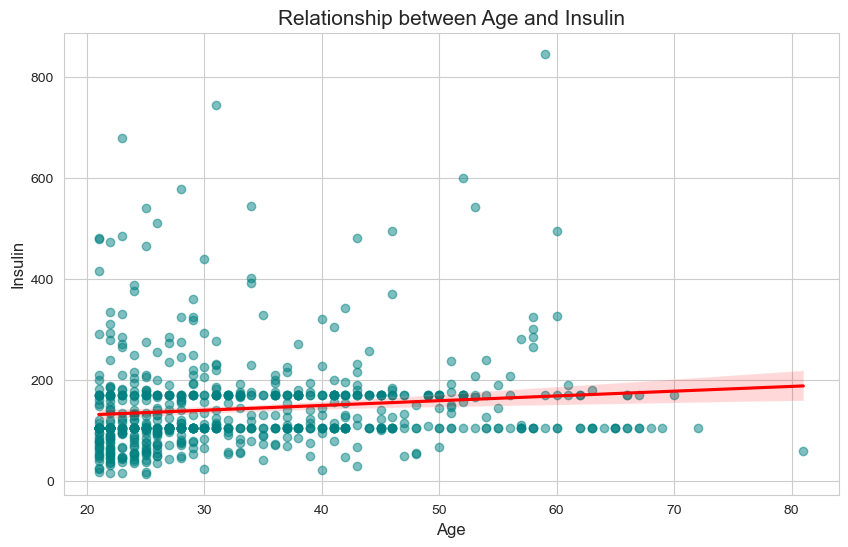

In [44]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Scatter plot and trend plot(red regplot)
sns.regplot(x='Age', y='Insulin', data=df, 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Relationship between Age and Insulin', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

plt.show()

#### Justification of my choice of test

We are measuring relationship between 2 numerical columns. Usually Pearson Correlation is used, but here data is not normally distributed , data is right-skewed. In addition, Pearson test can change result because of outliers. That's why I choose Spearman's Rank Correlation because it is a non-parametric test that relies on ranks rather than raw values, making it more robust against skewed data and outliers. Also Spearman is more effective for measuring not only linear but also monotonic relationships.

In [45]:
from scipy.stats import spearmanr

# We calculate the relationship between the Age and Insulin columns
rho, p_value_3 = spearmanr(df['Age'], df['Insulin'])

print(f"Spearman Correlation Coefficient (rho): {rho.round(3)}")
print(f"P-value: {p_value_3}")

Spearman Correlation Coefficient (rho): 0.239
P-value: 2.75565209567795e-11


#### Conclusion

p < 0.05, it shows that there is a statistically significant relationship between age and insulin levels and we reject $H_0$

rho = 0.239
0.1 < rho < 0.3, it shows a weak positive correlation

As patients get older, their insulin levels tend to increase, but this relationship is relatively weak. This suggests that while age is a factor, it is not the dominant driver of insulin concentration in this dataset. Other factors (like BMI or Glucose) likely play a much larger role in determining insulin levels

## Task 3

### Mean difference

In [46]:
# Confidence Interval for Mean Difference
import statsmodels.stats.api as sms

# I choose groups
group1 = df[df['Outcome'] == 1]['Glucose']
group2 = df[df['Outcome'] == 0]['Glucose']

# 95% CI calculation

# it calculates mean, standard deviation, count of each group 
cm = sms.CompareMeans(sms.DescrStatsW(group1), sms.DescrStatsW(group2))

conf_int = cm.tconfint_diff(alpha=0.05, alternative='two-sided', usevar='unequal')

print(f"95% Confidence Interval for Mean Difference: {conf_int}")

95% Confidence Interval for Mean Difference: (np.float64(27.486979332958704), np.float64(35.84939112475384))


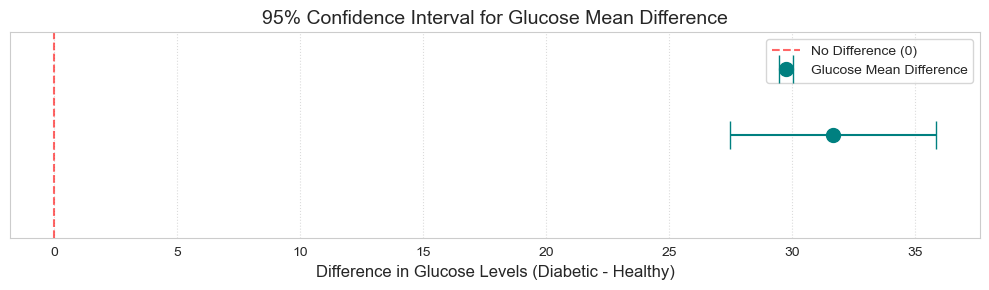

In [47]:
# Forest plot for Mean difference
import matplotlib.pyplot as plt

lower_m, upper_m = 27.486, 35.849
mean_est = (lower_m + upper_m) / 2 

plt.figure(figsize=(10, 3))

plt.errorbar(x=mean_est, y=0, xerr=[[mean_est - lower_m], [upper_m - mean_est]], 
             fmt='o', color='teal', ecolor='teal', capsize=10, markersize=10, label='Glucose Mean Difference')

plt.axvline(x=0, color='red', linestyle='--', alpha=0.6, label='No Difference (0)')

plt.yticks([])
plt.xlabel('Difference in Glucose Levels (Diabetic - Healthy)', fontsize=12)
plt.title('95% Confidence Interval for Glucose Mean Difference', fontsize=14)
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation for mean difference

This interval [27.49, 35.85] is positive and doesn't include 0. It says that in the population, glucose levels of diabetic patients are always higher than those of healthy people. This result verifies the hypothesis test result, it means that the difference between means is not random

### Proportion

In [48]:
# Confidence Interval for Proportion
from statsmodels.stats.proportion import proportion_confint

# count of diabetic patients
count = df['Outcome'].sum() 

# total number of people
nobs = len(df)              

# 95% CI hesablanması (Wilson metodu daha dəqiq hesab olunur)
ci_low, ci_upp = proportion_confint(count, nobs, alpha=0.05, method='wilson')

print(f"95% CI for Proportion of Diabetes: [{round(ci_low, 3)}, {round(ci_upp, 3)}]")

95% CI for Proportion of Diabetes: [0.318, 0.386]


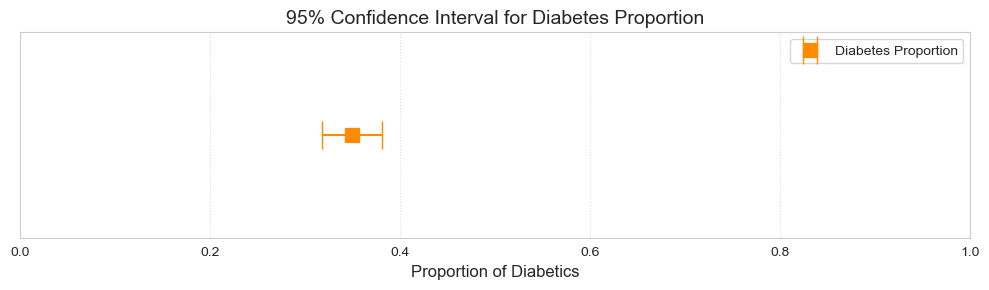

In [49]:
# Error-bar plot for Proportion
lower_p, upper_p = 0.318, 0.381
prop_est = (lower_p + upper_p) / 2

plt.figure(figsize=(10, 3))

plt.errorbar(x=prop_est, y=0, xerr=[[prop_est - lower_p], [upper_p - prop_est]], 
             fmt='s', color='darkorange', ecolor='darkorange', capsize=10, markersize=10, label='Diabetes Proportion')

plt.yticks([])
plt.xlabel('Proportion of Diabetics', fontsize=12)
plt.title('95% Confidence Interval for Diabetes Proportion', fontsize=14)
plt.xlim(0, 1) 
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

#### Interpretation for Proportion

According to this interval [0.318, 0.386], the prevalence of diabetes in the population is relatively moderate, staying well below 40%. Narrow range of this interval indicates a high level of precision in our estimate.

According the observed proportion, we can confidently state that the majority of the population in this dataset is non-diabetic, as the upper bound of the interval does not reach 50%.

## Task 4

I perform  a post-hoc power analysis on Mann-Whitney U test - relationship between BMI and diabetic and healthy patients

In [50]:
from statsmodels.stats.power import TTestIndPower

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pool_std
    

# I divide into groups 
group1_bmi = df[df['Outcome'] == 1]['BMI']
group2_bmi = df[df['Outcome'] == 0]['BMI']

# effect size
d_bmi = cohen_d(group1_bmi, group2_bmi)

print(f"Effect size for BMI (Cohen's d): {d_bmi:.3f}")

# power analysis
analysis = TTestIndPower()
power_bmi = analysis.power(effect_size=d_bmi, 
                           nobs1=len(group1_bmi), 
                           ratio=len(group2_bmi)/len(group1_bmi), 
                           alpha=0.05)

print(f"Power of the Test for BMI: {power_bmi:.3f}")

Effect size for BMI (Cohen's d): 0.691
Power of the Test for BMI: 1.000


In [51]:
alpha = 0.05
effect_size = 0.691
power = 0.80

required_sample = analysis.solve_power(
    effect_size = effect_size,
    alpha=alpha,
    power=power,
    ratio =1,
    nobs1 = None)

print(f"  Required n per group: {int(np.ceil(required_sample))}")
print(f"  Total participants: {2 * int(np.ceil(required_sample))}")


  Required n per group: 34
  Total participants: 68


I think that the dataset provides highly sufficient power, as the actual sample size 757 exceeds the required minimum 68 to detect the observed effect. With a statistical power of 1.0, the probability of a Type II error is practically eliminated. This confirms that the observed relationship between BMI and Diabetes is not only statistically significant but also reliable and robust, providing a solid foundation for our conclusions

## Task 5

The main goal of this reserach (all test, visualisation, detecting ditributions) is to detect the most critical biological factor for diagnosing diabet early. The main question is this: "How reliable are a patient's glucose level and body mass index (BMI) in diagnosing diabetes, and how much can we trust this data?"

Analysis shows that both glucose levels and BMI have a direct and strong relationship with diabetes.

Hypothesis, statistics tests, power and effecr size verifies that the glucose levels of diabetic patients are on average 30 units higher than those of healthy people. That's why Glucose is considered the most effective and fast way for detecting diabet.

Also, excess weight (BMI) significantly increases the risk of diabetes. The BMI of patients with diabetes is significantly higher than that of healthy people.

I analyzed data from 757 people. The calculations show that data from just 68 people would have been enough to produce these results with the same level of accuracy. I can say with 95% confidence that the glucose difference between diabetic and healthy people will remain stable around our estimated 30 units in real life.

Although these strong ststistic analysis, there are some constraints, because this dataset covers a specific time period.In addition, age, fasting, phisical activity and genteic factors are not considered.